In [1]:
# ============================================================
# RQ1 Reproducibility Builder
# Generates ONLY the numeric results used in the RQ1 section:
# - Base and Layer-2-observable counts
# - Table 3 medians
# - Pairwise MWU p-values and Cliff's delta values cited in
#   Obs. 1.1 to Obs. 1.5
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ1
#
# Outputs:
#   - rq1_counts.csv
#   - rq1_table3_medians.csv
#   - rq1_pairwise_statistics.csv
#   - rq1_numbers_bundle.xlsx
#   - rq1_run_notes.txt
#
# It also prints the generated numeric outputs to the console.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"3.0-Observations\RQ1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]

def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True, "false": False,
        "1": True, "0": False,
        "yes": True, "no": False,
        "y": True, "n": False,
        "base": True, "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)

def canon_style(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)

def cliff_delta(x: pd.Series, y: pd.Series) -> float:
    x = to_num(x).dropna().to_numpy()
    y = to_num(y).dropna().to_numpy()
    if len(x) == 0 or len(y) == 0:
        return np.nan
    u = mannwhitneyu(x, y, alternative="two-sided").statistic
    return float((2 * u) / (len(x) * len(y)) - 1)

def mwu_stats(df: pd.DataFrame, style_a: str, style_b: str, value_col: str) -> dict:
    x = to_num(df.loc[df["style"] == style_a, value_col]).dropna()
    y = to_num(df.loc[df["style"] == style_b, value_col]).dropna()
    if len(x) == 0 or len(y) == 0:
        return {
            "style_a": style_a,
            "style_b": style_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.nan,
            "median_b": np.nan,
            "p_value": np.nan,
            "cliffs_delta": np.nan,
        }
    p = float(mannwhitneyu(x, y, alternative="two-sided").pvalue)
    d = cliff_delta(x, y)
    return {
        "style_a": style_a,
        "style_b": style_b,
        "n_a": len(x),
        "n_b": len(y),
        "median_a": float(x.median()),
        "median_b": float(y.median()),
        "p_value": p,
        "cliffs_delta": d,
    }

def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")

def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

required_cols = [
    "style",
    "Base_timing_regime",
    "Layer2_available_in_base",
    "study_run_duration_seconds",
    "study_layer1_time_to_instrumentation_envelope_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_layer1_post_instrumentation_tail_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["style"] = df["style"].map(canon_style)
df["Base_timing_regime"] = norm_bool(df["Base_timing_regime"])
df["Layer2_available_in_base"] = norm_bool(df["Layer2_available_in_base"])

measure_cols = {
    "run_duration": "study_run_duration_seconds",
    "time_to_instr": "study_layer1_time_to_instrumentation_envelope_seconds",
    "instr_env": "study_layer1_instrumentation_job_envelope_seconds",
    "post_instr": "study_layer1_post_instrumentation_tail_seconds",
    "pre_invoc": "study_pre_invocation_selected_stage3_seconds",
    "exec_window": "study_invocation_execution_window_selected_stage3_seconds",
    "post_invoc": "study_post_invocation_selected_stage3_seconds",
}
for c in measure_cols.values():
    df[c] = to_num(df[c])

# ------------------------------------------------------------
# Controlled subsets
# ------------------------------------------------------------
base_df = df.loc[df["Base_timing_regime"] & df["style"].isin(STYLE_ORDER)].copy()
l2_base_df = base_df.loc[base_df["Layer2_available_in_base"]].copy()

# ------------------------------------------------------------
# Counts used in RQ1 intro
# ------------------------------------------------------------
rq1_counts = pd.DataFrame([
    {"metric": "Base_n", "value": int(len(base_df))},
    {"metric": "Layer2_observable_Base_n", "value": int(len(l2_base_df))},
])

# ------------------------------------------------------------
# Table 3 medians
# ------------------------------------------------------------
table3_rows = []
for style in STYLE_ORDER:
    part = base_df.loc[base_df["style"] == style].copy()
    part_l2 = l2_base_df.loc[l2_base_df["style"] == style].copy()

    table3_rows.append({
        "Style": style,
        "Run dur.": part["study_run_duration_seconds"].median(),
        "Time to instr.": part["study_layer1_time_to_instrumentation_envelope_seconds"].median(),
        "Instr. env.": part["study_layer1_instrumentation_job_envelope_seconds"].median(),
        "Post-instr.": part["study_layer1_post_instrumentation_tail_seconds"].median(),
        "Pre-invoc.": part_l2["study_pre_invocation_selected_stage3_seconds"].median(),
        "Exec. window": part_l2["study_invocation_execution_window_selected_stage3_seconds"].median(),
        "Post-invoc.": part_l2["study_post_invocation_selected_stage3_seconds"].median(),
    })

rq1_table3 = pd.DataFrame(table3_rows)

# ------------------------------------------------------------
# Pairwise statistics cited in Obs. 1.1 to 1.5
# ------------------------------------------------------------
stats_rows = []

# Obs. 1.1
for b in ["GMD", "Third-Party", "Custom"]:
    r = mwu_stats(base_df, "Community", b, "study_run_duration_seconds")
    r["observation"] = "Obs. 1.1"
    r["comparison"] = f"Community vs. {b}"
    r["metric"] = "Run duration"
    stats_rows.append(r)

# Obs. 1.2
r = mwu_stats(base_df, "GMD", "Community", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Community"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(base_df, "GMD", "Custom", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Custom"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "GMD", "Third-Party", "study_pre_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Third-Party"
r["metric"] = "Pre-invoc."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "GMD", "Community", "study_invocation_execution_window_selected_stage3_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Community"
r["metric"] = "Exec. window"
stats_rows.append(r)

r = mwu_stats(base_df, "GMD", "Community", "study_run_duration_seconds")
r["observation"] = "Obs. 1.2"
r["comparison"] = "GMD vs. Community"
r["metric"] = "Run duration"
stats_rows.append(r)

# Obs. 1.3
r = mwu_stats(base_df, "Third-Party", "Community", "study_run_duration_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Community"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Community", "study_invocation_execution_window_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Community"
r["metric"] = "Exec. window"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "GMD", "study_pre_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Pre-invoc."
stats_rows.append(r)

r = mwu_stats(base_df, "Third-Party", "Custom", "study_run_duration_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Custom"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Custom", "study_pre_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Custom"
r["metric"] = "Pre-invoc."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Custom", "study_invocation_execution_window_selected_stage3_seconds")
r["observation"] = "Obs. 1.3"
r["comparison"] = "Third-Party vs. Custom"
r["metric"] = "Exec. window"
stats_rows.append(r)

# Obs. 1.4
r = mwu_stats(base_df, "Custom", "Community", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "Third-Party", "study_layer1_time_to_instrumentation_envelope_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Third-Party"
r["metric"] = "Time to instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "Community", "study_run_duration_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "GMD", "study_run_duration_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. GMD"
r["metric"] = "Run duration"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Custom", "GMD", "study_post_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. GMD"
r["metric"] = "Post-invoc."
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Custom", "Third-Party", "study_post_invocation_selected_stage3_seconds")
r["observation"] = "Obs. 1.4"
r["comparison"] = "Custom vs. Third-Party"
r["metric"] = "Post-invoc."
stats_rows.append(r)

# Obs. 1.5
r = mwu_stats(base_df, "Community", "GMD", "study_layer1_post_instrumentation_tail_seconds")
r["observation"] = "Obs. 1.5"
r["comparison"] = "Community vs. GMD"
r["metric"] = "Post-instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Third-Party", "study_layer1_post_instrumentation_tail_seconds")
r["observation"] = "Obs. 1.5"
r["comparison"] = "Community vs. Third-Party"
r["metric"] = "Post-instr."
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Custom", "study_layer1_post_instrumentation_tail_seconds")
r["observation"] = "Obs. 1.5"
r["comparison"] = "Community vs. Custom"
r["metric"] = "Post-instr."
stats_rows.append(r)

rq1_stats = pd.DataFrame(stats_rows)

# Reorder columns
rq1_stats = rq1_stats[
    [
        "observation", "comparison", "metric",
        "style_a", "style_b",
        "n_a", "n_b",
        "median_a", "median_b",
        "p_value", "cliffs_delta",
    ]
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_csv(rq1_counts, OUT_DIR / "rq1_counts.csv")
save_csv(rq1_table3, OUT_DIR / "rq1_table3_medians.csv")
save_csv(rq1_stats, OUT_DIR / "rq1_pairwise_statistics.csv")

xlsx_path = OUT_DIR / "rq1_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq1_counts.to_excel(writer, sheet_name="counts", index=False)
    rq1_table3.to_excel(writer, sheet_name="table3_medians", index=False)
    rq1_stats.to_excel(writer, sheet_name="pairwise_stats", index=False)

notes = []
notes.append("RQ1 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regimes:")
notes.append("- Base subset: Base_timing_regime == True")
notes.append("- Layer 2 subset: Base_timing_regime == True AND Layer2_available_in_base == True")
notes.append("")
notes.append("Generated files:")
notes.append("- rq1_counts.csv")
notes.append("- rq1_table3_medians.csv")
notes.append("- rq1_pairwise_statistics.csv")
notes.append("- rq1_numbers_bundle.xlsx")

(OUT_DIR / "rq1_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------
print_section("RQ1 COUNTS", rq1_counts)
print_section("RQ1 TABLE 3 MEDIANS", rq1_table3)
print_section("RQ1 PAIRWISE STATISTICS", rq1_stats)

print("\nSaved outputs to:")
print(OUT_DIR)


RQ1 COUNTS
                  metric  value
                  Base_n   7744
Layer2_observable_Base_n   5057

RQ1 TABLE 3 MEDIANS
      Style  Run dur.  Time to instr.  Instr. env.  Post-instr.  Pre-invoc.  Exec. window  Post-invoc.
  Community     883.0             4.0        624.0          7.0       187.0         397.0         75.0
        GMD    1212.0             3.0       1208.0          1.0        79.5        1076.0          4.0
Third-Party    1864.5             4.0       1717.5          1.0       561.0        1881.5          5.0
     Custom    1817.0             3.0       1609.5          1.0       131.5         726.0        942.5

RQ1 PAIRWISE STATISTICS
observation                comparison         metric     style_a     style_b  n_a  n_b  median_a  median_b      p_value  cliffs_delta
   Obs. 1.1         Community vs. GMD   Run duration   Community         GMD 6921  263     883.0    1212.0 1.898032e-11     -0.243529
   Obs. 1.1 Community vs. Third-Party   Run duration   Communit

In [ ]:
##RQ2

In [2]:
# ============================================================
# RQ2 Reproducibility Builder
# Generates ONLY the numeric results used in the RQ2 section:
# - Base count
# - Table 4 predictability values
# - Pairwise MWU p-values and Cliff's delta values cited in
#   Obs. 2.1 to Obs. 2.4
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ2
#
# Outputs:
#   - rq2_counts.csv
#   - rq2_table4_predictability_profile.csv
#   - rq2_pairwise_statistics.csv
#   - rq2_numbers_bundle.xlsx
#   - rq2_run_notes.txt
#
# It also prints the generated numeric outputs to the console.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"3.0-Observations\RQ2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]

def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True, "false": False,
        "1": True, "0": False,
        "yes": True, "no": False,
        "y": True, "n": False,
        "base": True, "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)

def canon_style(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)

def cliff_delta(x: pd.Series, y: pd.Series) -> float:
    x = to_num(x).dropna().to_numpy()
    y = to_num(y).dropna().to_numpy()
    if len(x) == 0 or len(y) == 0:
        return np.nan
    u = mannwhitneyu(x, y, alternative="two-sided").statistic
    return float((2 * u) / (len(x) * len(y)) - 1)

def mwu_stats(df: pd.DataFrame, style_a: str, style_b: str, value_col: str) -> dict:
    x = to_num(df.loc[df["style"] == style_a, value_col]).dropna()
    y = to_num(df.loc[df["style"] == style_b, value_col]).dropna()
    if len(x) == 0 or len(y) == 0:
        return {
            "style_a": style_a,
            "style_b": style_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.nan,
            "median_b": np.nan,
            "p_value": np.nan,
            "cliffs_delta": np.nan,
        }
    p = float(mannwhitneyu(x, y, alternative="two-sided").pvalue)
    d = cliff_delta(x, y)
    return {
        "style_a": style_a,
        "style_b": style_b,
        "n_a": len(x),
        "n_b": len(y),
        "median_a": float(x.median()),
        "median_b": float(y.median()),
        "p_value": p,
        "cliffs_delta": d,
    }

def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")

def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))

def add_norm_abs_dev(df_part: pd.DataFrame, measure_col: str, out_col: str) -> pd.DataFrame:
    out = df_part.copy()
    med_by_style = (
        out.groupby("style")[measure_col]
        .median()
        .rename("_style_median")
        .reset_index()
    )
    out = out.merge(med_by_style, on="style", how="left")
    out[out_col] = (to_num(out[measure_col]) - to_num(out["_style_median"])).abs() / to_num(out["_style_median"])
    out = out.drop(columns=["_style_median"])
    return out

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

required_cols = [
    "style",
    "Base_timing_regime",
    "Layer2_available_in_base",
    "study_run_duration_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["style"] = df["style"].map(canon_style)
df["Base_timing_regime"] = norm_bool(df["Base_timing_regime"])
df["Layer2_available_in_base"] = norm_bool(df["Layer2_available_in_base"])

for col in [
    "study_run_duration_seconds",
    "study_layer1_instrumentation_job_envelope_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
]:
    df[col] = to_num(df[col])

# ------------------------------------------------------------
# Controlled subsets
# ------------------------------------------------------------
base_df = df.loc[df["Base_timing_regime"] & df["style"].isin(STYLE_ORDER)].copy()
l2_base_df = base_df.loc[base_df["Layer2_available_in_base"]].copy()

# ------------------------------------------------------------
# Derived predictability measures
# ------------------------------------------------------------
base_df = add_norm_abs_dev(base_df, "study_run_duration_seconds", "nad_run_duration")
base_df = add_norm_abs_dev(base_df, "study_layer1_instrumentation_job_envelope_seconds", "nad_instr_env")

l2_base_df = add_norm_abs_dev(
    l2_base_df,
    "study_invocation_execution_window_selected_stage3_seconds",
    "nad_exec_window"
)
l2_base_df = add_norm_abs_dev(
    l2_base_df,
    "study_pre_invocation_selected_stage3_seconds",
    "nad_pre_invocation"
)

# ------------------------------------------------------------
# Counts used in RQ2 intro
# ------------------------------------------------------------
rq2_counts = pd.DataFrame([
    {"metric": "Base_n", "value": int(len(base_df))},
    {"metric": "Layer2_observable_Base_n", "value": int(len(l2_base_df))},
])

# ------------------------------------------------------------
# Table 4 predictability profile
# ------------------------------------------------------------
rows = []
for style in STYLE_ORDER:
    part = base_df.loc[base_df["style"] == style].copy()
    part_l2 = l2_base_df.loc[l2_base_df["style"] == style].copy()

    run_median = float(part["study_run_duration_seconds"].median()) if len(part) else np.nan
    p95_run = float(part["study_run_duration_seconds"].quantile(0.95)) if len(part) else np.nan

    rows.append({
        "Style": style,
        "Norm. abs. dev. (run dur.)": float(part["nad_run_duration"].median()) if len(part) else np.nan,
        "Norm. abs. dev. (Instr. env.)": float(part["nad_instr_env"].median()) if len(part) else np.nan,
        "Norm. abs. dev. (L2 exec. window)": float(part_l2["nad_exec_window"].median()) if len(part_l2) else np.nan,
        "Norm. abs. dev. (L2 pre-invoc.)": float(part_l2["nad_pre_invocation"].median()) if len(part_l2) else np.nan,
        "P95 run dur. (s)": p95_run,
        "P95 / median (run dur.)": (p95_run / run_median) if pd.notna(p95_run) and pd.notna(run_median) and run_median != 0 else np.nan,
        "Median run dur. (s)": run_median,
        "Median Instr. env. (s)": float(part["study_layer1_instrumentation_job_envelope_seconds"].median()) if len(part) else np.nan,
        "Median L2 exec. window (s)": float(part_l2["study_invocation_execution_window_selected_stage3_seconds"].median()) if len(part_l2) else np.nan,
    })

rq2_table4 = pd.DataFrame(rows)

# ------------------------------------------------------------
# Pairwise statistics cited in Obs. 2.1 to 2.4
# ------------------------------------------------------------
stats_rows = []

# Obs. 2.1
for b in ["Community", "Custom", "Third-Party"]:
    r = mwu_stats(base_df, "GMD", b, "nad_run_duration")
    r["observation"] = "Obs. 2.1"
    r["comparison"] = f"GMD vs. {b}"
    r["metric"] = "Norm. abs. dev. (run dur.)"
    stats_rows.append(r)

# Obs. 2.2
r = mwu_stats(base_df, "Community", "GMD", "nad_run_duration")
r["observation"] = "Obs. 2.2"
r["comparison"] = "Community vs. GMD"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Custom", "nad_run_duration")
r["observation"] = "Obs. 2.2"
r["comparison"] = "Community vs. Custom"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Community", "Custom", "nad_instr_env")
r["observation"] = "Obs. 2.2"
r["comparison"] = "Community vs. Custom"
r["metric"] = "Norm. abs. dev. (Instr. env.)"
stats_rows.append(r)

# Obs. 2.3
r = mwu_stats(base_df, "Third-Party", "GMD", "nad_run_duration")
r["observation"] = "Obs. 2.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Third-Party", "GMD", "nad_instr_env")
r["observation"] = "Obs. 2.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Norm. abs. dev. (Instr. env.)"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "GMD", "nad_exec_window")
r["observation"] = "Obs. 2.3"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "Norm. abs. dev. (L2 exec. window)"
stats_rows.append(r)

# Obs. 2.4
r = mwu_stats(base_df, "Custom", "Community", "nad_run_duration")
r["observation"] = "Obs. 2.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Norm. abs. dev. (run dur.)"
stats_rows.append(r)

r = mwu_stats(base_df, "Custom", "Community", "nad_instr_env")
r["observation"] = "Obs. 2.4"
r["comparison"] = "Custom vs. Community"
r["metric"] = "Norm. abs. dev. (Instr. env.)"
stats_rows.append(r)

rq2_stats = pd.DataFrame(stats_rows)
rq2_stats = rq2_stats[
    [
        "observation", "comparison", "metric",
        "style_a", "style_b",
        "n_a", "n_b",
        "median_a", "median_b",
        "p_value", "cliffs_delta",
    ]
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_csv(rq2_counts, OUT_DIR / "rq2_counts.csv")
save_csv(rq2_table4, OUT_DIR / "rq2_table4_predictability_profile.csv")
save_csv(rq2_stats, OUT_DIR / "rq2_pairwise_statistics.csv")

xlsx_path = OUT_DIR / "rq2_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq2_counts.to_excel(writer, sheet_name="counts", index=False)
    rq2_table4.to_excel(writer, sheet_name="table4_profile", index=False)
    rq2_stats.to_excel(writer, sheet_name="pairwise_stats", index=False)

notes = []
notes.append("RQ2 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regimes:")
notes.append("- Base subset: Base_timing_regime == True")
notes.append("- Layer 2 subset: Base_timing_regime == True AND Layer2_available_in_base == True")
notes.append("")
notes.append("Derived measures:")
notes.append("- Normalized absolute deviation = |x - style_median| / style_median")
notes.append("- P95 run duration = 95th percentile within style under Base")
notes.append("- P95/median = P95 run duration / style median run duration")
notes.append("")
notes.append("Generated files:")
notes.append("- rq2_counts.csv")
notes.append("- rq2_table4_predictability_profile.csv")
notes.append("- rq2_pairwise_statistics.csv")
notes.append("- rq2_numbers_bundle.xlsx")

(OUT_DIR / "rq2_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------
print_section("RQ2 COUNTS", rq2_counts)
print_section("RQ2 TABLE 4 PREDICTABILITY PROFILE", rq2_table4)
print_section("RQ2 PAIRWISE STATISTICS", rq2_stats)

print("\nSaved outputs to:")
print(OUT_DIR)


RQ2 COUNTS
                  metric  value
                  Base_n   7744
Layer2_observable_Base_n   5057

RQ2 TABLE 4 PREDICTABILITY PROFILE
      Style  Norm. abs. dev. (run dur.)  Norm. abs. dev. (Instr. env.)  Norm. abs. dev. (L2 exec. window)  Norm. abs. dev. (L2 pre-invoc.)  P95 run dur. (s)  P95 / median (run dur.)  Median run dur. (s)  Median Instr. env. (s)  Median L2 exec. window (s)
  Community                    0.506229                       0.511218                           0.513854                         0.914439           13909.0                15.751982                883.0                   624.0                       397.0
        GMD                    0.061056                       0.059603                           0.044610                         0.106918            1483.4                 1.223927               1212.0                  1208.0                      1076.0
Third-Party                    0.256101                       0.233479                     

In [ ]:
#RQ3

In [3]:
# ============================================================
# RQ3 Reproducibility Builder
# Generates ONLY the numeric results used in the RQ3 section:
# - Base count
# - Layer-2-included Base count
# - Table 5 Layer 2 share medians by style
# - Pairwise MWU p-values and Cliff's delta values cited in
#   Obs. 3.1 to Obs. 3.4
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ3
#
# Outputs:
#   - rq3_counts.csv
#   - rq3_table5_share_medians.csv
#   - rq3_pairwise_statistics.csv
#   - rq3_numbers_bundle.xlsx
#   - rq3_run_notes.txt
#
# It also prints the generated numeric outputs to the console.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"3.0-Observations\RQ3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]

def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True, "false": False,
        "1": True, "0": False,
        "yes": True, "no": False,
        "y": True, "n": False,
        "base": True, "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)

def canon_style(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)

def cliff_delta(x: pd.Series, y: pd.Series) -> float:
    x = to_num(x).dropna().to_numpy()
    y = to_num(y).dropna().to_numpy()
    if len(x) == 0 or len(y) == 0:
        return np.nan
    u = mannwhitneyu(x, y, alternative="two-sided").statistic
    return float((2 * u) / (len(x) * len(y)) - 1)

def mwu_stats(df: pd.DataFrame, style_a: str, style_b: str, value_col: str) -> dict:
    x = to_num(df.loc[df["style"] == style_a, value_col]).dropna()
    y = to_num(df.loc[df["style"] == style_b, value_col]).dropna()
    if len(x) == 0 or len(y) == 0:
        return {
            "style_a": style_a,
            "style_b": style_b,
            "n_a": len(x),
            "n_b": len(y),
            "median_a": np.nan,
            "median_b": np.nan,
            "p_value": np.nan,
            "cliffs_delta": np.nan,
        }
    p = float(mannwhitneyu(x, y, alternative="two-sided").pvalue)
    d = cliff_delta(x, y)
    return {
        "style_a": style_a,
        "style_b": style_b,
        "n_a": len(x),
        "n_b": len(y),
        "median_a": float(x.median()),
        "median_b": float(y.median()),
        "p_value": p,
        "cliffs_delta": d,
    }

def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")

def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

required_cols = [
    "style",
    "Base_timing_regime",
    "Layer2_available_in_base",
    "study_run_duration_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["style"] = df["style"].map(canon_style)
df["Base_timing_regime"] = norm_bool(df["Base_timing_regime"])
df["Layer2_available_in_base"] = norm_bool(df["Layer2_available_in_base"])

for col in [
    "study_run_duration_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
]:
    df[col] = to_num(df[col])

# ------------------------------------------------------------
# Controlled subsets
# ------------------------------------------------------------
base_df = df.loc[df["Base_timing_regime"] & df["style"].isin(STYLE_ORDER)].copy()
l2_base_df = base_df.loc[base_df["Layer2_available_in_base"]].copy()

# ------------------------------------------------------------
# Derived share measures
# ------------------------------------------------------------
den = l2_base_df["study_run_duration_seconds"].replace(0, np.nan)

l2_base_df["share_pre"] = (
    l2_base_df["study_pre_invocation_selected_stage3_seconds"] / den
)
l2_base_df["share_exec"] = (
    l2_base_df["study_invocation_execution_window_selected_stage3_seconds"] / den
)
l2_base_df["share_post"] = (
    l2_base_df["study_post_invocation_selected_stage3_seconds"] / den
)

# ------------------------------------------------------------
# Counts used in RQ3 intro
# ------------------------------------------------------------
rq3_counts = pd.DataFrame([
    {"metric": "Base_n", "value": int(len(base_df))},
    {"metric": "Layer2_included_Base_n", "value": int(len(l2_base_df))},
])

# ------------------------------------------------------------
# Table 5 numeric share medians
# ------------------------------------------------------------
table5_rows = []
for style in STYLE_ORDER:
    part = l2_base_df.loc[l2_base_df["style"] == style].copy()
    table5_rows.append({
        "Style": style,
        "Pre share median": float(part["share_pre"].median()) if len(part) else np.nan,
        "Exec share median": float(part["share_exec"].median()) if len(part) else np.nan,
        "Post share median": float(part["share_post"].median()) if len(part) else np.nan,
    })

rq3_table5 = pd.DataFrame(table5_rows)

# Optional percent-friendly display copy
rq3_table5_percent = rq3_table5.copy()
for c in ["Pre share median", "Exec share median", "Post share median"]:
    rq3_table5_percent[c] = rq3_table5_percent[c] * 100

# ------------------------------------------------------------
# Pairwise statistics cited in Obs. 3.1 to Obs. 3.4
# ------------------------------------------------------------
stats_rows = []

# Obs. 3.1
r = mwu_stats(l2_base_df, "GMD", "Community", "share_exec")
r["observation"] = "Obs. 3.1"
r["comparison"] = "GMD vs. Community"
r["metric"] = "L2 execution share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "GMD", "Third-Party", "share_exec")
r["observation"] = "Obs. 3.1"
r["comparison"] = "GMD vs. Third-Party"
r["metric"] = "L2 execution share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "GMD", "Community", "share_post")
r["observation"] = "Obs. 3.1"
r["comparison"] = "GMD vs. Community"
r["metric"] = "L2 post-invocation share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "GMD", "Custom", "share_post")
r["observation"] = "Obs. 3.1"
r["comparison"] = "GMD vs. Custom"
r["metric"] = "L2 post-invocation share"
stats_rows.append(r)

# Obs. 3.2
r = mwu_stats(l2_base_df, "Third-Party", "GMD", "share_pre")
r["observation"] = "Obs. 3.2"
r["comparison"] = "Third-Party vs. GMD"
r["metric"] = "L2 pre-invocation share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Community", "share_exec")
r["observation"] = "Obs. 3.2"
r["comparison"] = "Third-Party vs. Community"
r["metric"] = "L2 execution share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Third-Party", "Community", "share_post")
r["observation"] = "Obs. 3.2"
r["comparison"] = "Third-Party vs. Community"
r["metric"] = "L2 post-invocation share"
stats_rows.append(r)

# Obs. 3.3
r = mwu_stats(l2_base_df, "Community", "GMD", "share_exec")
r["observation"] = "Obs. 3.3"
r["comparison"] = "Community vs. GMD"
r["metric"] = "L2 execution share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Community", "Third-Party", "share_exec")
r["observation"] = "Obs. 3.3"
r["comparison"] = "Community vs. Third-Party"
r["metric"] = "L2 execution share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Community", "Third-Party", "share_post")
r["observation"] = "Obs. 3.3"
r["comparison"] = "Community vs. Third-Party"
r["metric"] = "L2 post-invocation share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Community", "Third-Party", "share_pre")
r["observation"] = "Obs. 3.3"
r["comparison"] = "Community vs. Third-Party"
r["metric"] = "L2 pre-invocation share"
stats_rows.append(r)

# Obs. 3.4
r = mwu_stats(l2_base_df, "Custom", "GMD", "share_post")
r["observation"] = "Obs. 3.4"
r["comparison"] = "Custom vs. GMD"
r["metric"] = "L2 post-invocation share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Custom", "Third-Party", "share_post")
r["observation"] = "Obs. 3.4"
r["comparison"] = "Custom vs. Third-Party"
r["metric"] = "L2 post-invocation share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Custom", "GMD", "share_exec")
r["observation"] = "Obs. 3.4"
r["comparison"] = "Custom vs. GMD"
r["metric"] = "L2 execution share"
stats_rows.append(r)

r = mwu_stats(l2_base_df, "Custom", "Third-Party", "share_exec")
r["observation"] = "Obs. 3.4"
r["comparison"] = "Custom vs. Third-Party"
r["metric"] = "L2 execution share"
stats_rows.append(r)

rq3_stats = pd.DataFrame(stats_rows)
rq3_stats = rq3_stats[
    [
        "observation", "comparison", "metric",
        "style_a", "style_b",
        "n_a", "n_b",
        "median_a", "median_b",
        "p_value", "cliffs_delta",
    ]
]

# Percent-friendly copy for easy paper lookup
rq3_stats_percent = rq3_stats.copy()
for c in ["median_a", "median_b"]:
    rq3_stats_percent[c] = rq3_stats_percent[c] * 100

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_csv(rq3_counts, OUT_DIR / "rq3_counts.csv")
save_csv(rq3_table5, OUT_DIR / "rq3_table5_share_medians_raw.csv")
save_csv(rq3_table5_percent, OUT_DIR / "rq3_table5_share_medians_percent.csv")
save_csv(rq3_stats, OUT_DIR / "rq3_pairwise_statistics_raw.csv")
save_csv(rq3_stats_percent, OUT_DIR / "rq3_pairwise_statistics_percent.csv")

xlsx_path = OUT_DIR / "rq3_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq3_counts.to_excel(writer, sheet_name="counts", index=False)
    rq3_table5.to_excel(writer, sheet_name="table5_raw", index=False)
    rq3_table5_percent.to_excel(writer, sheet_name="table5_percent", index=False)
    rq3_stats.to_excel(writer, sheet_name="pairwise_raw", index=False)
    rq3_stats_percent.to_excel(writer, sheet_name="pairwise_percent", index=False)

notes = []
notes.append("RQ3 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regimes:")
notes.append("- Base subset: Base_timing_regime == True")
notes.append("- Layer 2 subset: Base_timing_regime == True AND Layer2_available_in_base == True")
notes.append("")
notes.append("Derived measures:")
notes.append("- share_pre  = study_pre_invocation_selected_stage3_seconds / study_run_duration_seconds")
notes.append("- share_exec = study_invocation_execution_window_selected_stage3_seconds / study_run_duration_seconds")
notes.append("- share_post = study_post_invocation_selected_stage3_seconds / study_run_duration_seconds")
notes.append("")
notes.append("Files:")
notes.append("- rq3_counts.csv")
notes.append("- rq3_table5_share_medians_raw.csv")
notes.append("- rq3_table5_share_medians_percent.csv")
notes.append("- rq3_pairwise_statistics_raw.csv")
notes.append("- rq3_pairwise_statistics_percent.csv")
notes.append("- rq3_numbers_bundle.xlsx")

(OUT_DIR / "rq3_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------
print_section("RQ3 COUNTS", rq3_counts)
print_section("RQ3 TABLE 5 SHARE MEDIANS (RAW FRACTIONS)", rq3_table5)
print_section("RQ3 TABLE 5 SHARE MEDIANS (PERCENT)", rq3_table5_percent)
print_section("RQ3 PAIRWISE STATISTICS (RAW FRACTIONS)", rq3_stats)
print_section("RQ3 PAIRWISE STATISTICS (PERCENT MEDIANS)", rq3_stats_percent)

print("\nSaved outputs to:")
print(OUT_DIR)


RQ3 COUNTS
                metric  value
                Base_n   7744
Layer2_included_Base_n   5057

RQ3 TABLE 5 SHARE MEDIANS (RAW FRACTIONS)
      Style  Pre share median  Exec share median  Post share median
  Community          0.167614           0.393162           0.077143
        GMD          0.068030           0.926966           0.003970
Third-Party          0.232757           0.700653           0.002528
     Custom          0.074360           0.359364           0.564484

RQ3 TABLE 5 SHARE MEDIANS (PERCENT)
      Style  Pre share median  Exec share median  Post share median
  Community         16.761364          39.316239           7.714286
        GMD          6.802965          92.696609           0.396988
Third-Party         23.275694          70.065349           0.252795
     Custom          7.436009          35.936408          56.448368

RQ3 PAIRWISE STATISTICS (RAW FRACTIONS)
observation                comparison                   metric     style_a     style_b  n_a  n_b 

In [ ]:
#RQ 4

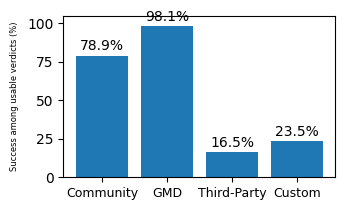

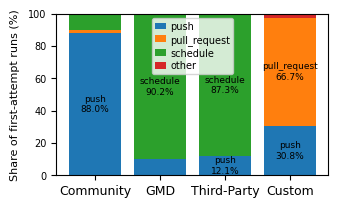


RQ4 COUNTS
                                  metric  value
First_attempt_instrumentation_executed_n   8603
                 Usable_verdict_subset_n   7744

RQ4 COMPACT PROFILE
      Style    Usable   Success              Trigger
  Community 89.142195 78.948129         push (88.0%)
        GMD 99.245283 98.098859     schedule (90.2%)
Third-Party 98.317757 16.539924     schedule (87.3%)
     Custom 87.179487 23.529412 pull_request (66.7%)

RQ4 OVERALL TESTS
                         test    n       p_value  cramers_v
Style x usable_verdict_status 8603  9.330926e-16   0.092169
 Style x success_among_usable 7744 2.026288e-247   0.384127
        Style x trigger_event 8603  0.000000e+00   0.397127

RQ4 TRIGGER-CONDITIONED TESTS
      Style  overall_n_usable  overall_p_value  overall_cramers_v  push_n_usable  push_n_success  push_success_pct  pull_request_n_usable  pull_request_n_success  pull_request_success_pct  schedule_n_usable  schedule_n_success  schedule_success_pct  other_n_usable  ot

In [2]:
# ============================================================
# RQ4 Reproducibility Builder
# Generates the numeric results and plots used in RQ4:
# - first-attempt instrumentation-executed regime counts
# - compact profile table (usable, success-among-usable, dominant trigger)
# - overall chi-square tests and effect sizes
# - style-level trigger-conditioned outcome tests
# - plot-ready distributions and saved figures
#
# Reads from:
#   C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
#
# Writes to:
#   C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ4
#
# Outputs:
#   - rq4_counts.csv
#   - rq4_compact_profile.csv
#   - rq4_overall_tests.csv
#   - rq4_trigger_conditioned_tests.csv
#   - rq4_success_among_usable_by_style.csv
#   - rq4_trigger_distribution_by_style.csv
#   - rq4_first_attempt_conclusion_distribution.csv
#   - rq4_numbers_bundle.xlsx
#   - rq4_success_among_usable_by_style.png
#   - rq4_trigger_distribution_by_style_100.png
#   - rq4_run_notes.txt
#
# It also prints the generated numeric outputs and shows the plots.
# ============================================================

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / r"C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]
TRIGGER_ORDER = ["push", "pull_request", "schedule", "other"]

def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def norm_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True, "false": False,
        "1": True, "0": False,
        "yes": True, "no": False,
        "y": True, "n": False,
        "base": True, "non-base": False,
    }
    return s.map(mapping).fillna(False).astype(bool)

def canon_style(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    mapping = {
        "community": "Community",
        "gmd": "GMD",
        "third-party": "Third-Party",
        "third party": "Third-Party",
        "custom": "Custom",
    }
    return mapping.get(s.lower(), s)

def canon_event(x):
    if pd.isna(x):
        return "other"
    s = str(x).strip().lower()
    if s == "push":
        return "push"
    if s == "pull_request":
        return "pull_request"
    if s == "schedule":
        return "schedule"
    return "other"

def canon_conclusion(x):
    if pd.isna(x):
        return "unknown"
    s = str(x).strip().lower()
    mapping = {
        "success": "success",
        "failure": "failure",
        "cancelled": "cancelled",
        "canceled": "cancelled",
        "timed_out": "timed_out",
        "skipped": "skipped",
        "action_required": "action_required",
        "startup_failure": "startup_failure",
        "stale": "stale",
        "neutral": "neutral",
    }
    return mapping.get(s, s)

def cramers_v(ct: pd.DataFrame) -> float:
    if ct.empty:
        return np.nan
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = ct.shape
    denom = n * max(1, min(r - 1, k - 1))
    return float(np.sqrt(chi2 / denom))

def chi_summary(ct: pd.DataFrame) -> tuple[float, float]:
    if ct.empty or ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan
    chi2, p, _, _ = chi2_contingency(ct)
    v = cramers_v(ct)
    return float(p), float(v)

def pct(num, den):
    if den == 0:
        return np.nan
    return 100.0 * num / den

def save_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False, encoding="utf-8-sig")

def print_section(title: str, df: pd.DataFrame):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    print(df.to_string(index=False))

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
if not IN_MAIN.exists():
    raise FileNotFoundError(f"MainDataset.csv not found: {IN_MAIN}")

df = pd.read_csv(IN_MAIN, low_memory=False)

required_cols = [
    "style",
    "controller_style_in_scope",
    "controller_instru_job_count_gt0",
    "controller_attempt_eq_1",
    "controller_usable_verdict",
    "run_conclusion",
    "event",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["style"] = df["style"].map(canon_style)
df["controller_style_in_scope"] = norm_bool(df["controller_style_in_scope"])
df["controller_instru_job_count_gt0"] = norm_bool(df["controller_instru_job_count_gt0"])
df["controller_attempt_eq_1"] = norm_bool(df["controller_attempt_eq_1"])
df["controller_usable_verdict"] = norm_bool(df["controller_usable_verdict"])
df["event_norm"] = df["event"].map(canon_event)
df["run_conclusion_norm"] = df["run_conclusion"].map(canon_conclusion)

# ------------------------------------------------------------
# RQ4 regime
# instrumentation-executed first-attempt run x style observations
# ------------------------------------------------------------
rq4_df = df.loc[
    df["style"].isin(STYLE_ORDER)
    & df["controller_style_in_scope"]
    & df["controller_instru_job_count_gt0"]
    & df["controller_attempt_eq_1"]
].copy()

usable_df = rq4_df.loc[rq4_df["controller_usable_verdict"]].copy()
usable_df["success_failure"] = np.where(
    usable_df["run_conclusion_norm"] == "success",
    "success",
    "failure"
)

# ------------------------------------------------------------
# Counts
# ------------------------------------------------------------
rq4_counts = pd.DataFrame([
    {"metric": "First_attempt_instrumentation_executed_n", "value": int(len(rq4_df))},
    {"metric": "Usable_verdict_subset_n", "value": int(len(usable_df))},
])

# ------------------------------------------------------------
# Compact profile table
# ------------------------------------------------------------
compact_rows = []
for style in STYLE_ORDER:
    part = rq4_df.loc[rq4_df["style"] == style].copy()
    part_usable = usable_df.loc[usable_df["style"] == style].copy()

    n_total = len(part)
    n_usable = len(part_usable)
    n_success = int((part_usable["run_conclusion_norm"] == "success").sum())

    event_dist = part["event_norm"].value_counts(dropna=False)
    dominant_trigger = event_dist.idxmax() if not event_dist.empty else np.nan
    dominant_trigger_pct = pct(int(event_dist.max()) if not event_dist.empty else 0, n_total)

    compact_rows.append({
        "Style": style,
        "n_total": n_total,
        "n_usable": n_usable,
        "usable_pct": pct(n_usable, n_total),
        "n_success_among_usable": n_success,
        "success_among_usable_pct": pct(n_success, n_usable),
        "dominant_trigger": dominant_trigger,
        "dominant_trigger_pct": dominant_trigger_pct,
    })

rq4_compact = pd.DataFrame(compact_rows)

# paper-friendly compact table
rq4_compact_profile = rq4_compact.copy()
rq4_compact_profile["Usable"] = rq4_compact_profile["usable_pct"]
rq4_compact_profile["Success"] = rq4_compact_profile["success_among_usable_pct"]
rq4_compact_profile["Trigger"] = (
    rq4_compact_profile["dominant_trigger"]
    + " ("
    + rq4_compact_profile["dominant_trigger_pct"].round(1).astype(str)
    + "%)"
)
rq4_compact_profile = rq4_compact_profile[["Style", "Usable", "Success", "Trigger"]]

# ------------------------------------------------------------
# Overall tests
# ------------------------------------------------------------
rq4_df["usable_status"] = np.where(rq4_df["controller_usable_verdict"], "usable", "non_usable")

ct_usable = pd.crosstab(rq4_df["style"], rq4_df["usable_status"])
p_usable, v_usable = chi_summary(ct_usable)

ct_success = pd.crosstab(usable_df["style"], usable_df["success_failure"])
p_success, v_success = chi_summary(ct_success)

ct_trigger = pd.crosstab(rq4_df["style"], rq4_df["event_norm"])
p_trigger, v_trigger = chi_summary(ct_trigger)

rq4_overall_tests = pd.DataFrame([
    {
        "test": "Style x usable_verdict_status",
        "n": int(ct_usable.to_numpy().sum()),
        "p_value": p_usable,
        "cramers_v": v_usable,
    },
    {
        "test": "Style x success_among_usable",
        "n": int(ct_success.to_numpy().sum()),
        "p_value": p_success,
        "cramers_v": v_success,
    },
    {
        "test": "Style x trigger_event",
        "n": int(ct_trigger.to_numpy().sum()),
        "p_value": p_trigger,
        "cramers_v": v_trigger,
    },
])

# ------------------------------------------------------------
# Trigger-conditioned outcome tests by style
# ------------------------------------------------------------
trigger_rows = []

for style in STYLE_ORDER:
    part = usable_df.loc[usable_df["style"] == style].copy()
    if part.empty:
        continue

    # all trigger categories together
    ct = pd.crosstab(part["event_norm"], part["success_failure"])
    p_all, v_all = chi_summary(ct)

    row = {
        "Style": style,
        "overall_n_usable": int(len(part)),
        "overall_p_value": p_all,
        "overall_cramers_v": v_all,
    }

    # success counts by trigger
    for trig in TRIGGER_ORDER:
        trig_part = part.loc[part["event_norm"] == trig].copy()
        n_trig = len(trig_part)
        n_success = int((trig_part["run_conclusion_norm"] == "success").sum())
        row[f"{trig}_n_usable"] = n_trig
        row[f"{trig}_n_success"] = n_success
        row[f"{trig}_success_pct"] = pct(n_success, n_trig)

    trigger_rows.append(row)

rq4_trigger_conditioned = pd.DataFrame(trigger_rows)

# ------------------------------------------------------------
# Plot-ready tables
# ------------------------------------------------------------
# Success among usable by style
success_plot_rows = []
for style in STYLE_ORDER:
    part = usable_df.loc[usable_df["style"] == style].copy()
    n_usable = len(part)
    n_success = int((part["run_conclusion_norm"] == "success").sum())
    success_plot_rows.append({
        "Style": style,
        "n_usable": n_usable,
        "n_success": n_success,
        "success_pct": pct(n_success, n_usable),
    })
rq4_success_plot = pd.DataFrame(success_plot_rows)

# Trigger distribution by style
trigger_plot = (
    rq4_df.groupby(["style", "event_norm"])
    .size()
    .rename("n")
    .reset_index()
)
all_style_event = pd.MultiIndex.from_product([STYLE_ORDER, TRIGGER_ORDER], names=["style", "event_norm"])
trigger_plot = (
    trigger_plot.set_index(["style", "event_norm"])
    .reindex(all_style_event, fill_value=0)
    .reset_index()
)
style_totals = trigger_plot.groupby("style")["n"].sum().rename("style_total").reset_index()
trigger_plot = trigger_plot.merge(style_totals, on="style", how="left")
trigger_plot["pct_within_style"] = np.where(
    trigger_plot["style_total"] > 0,
    100.0 * trigger_plot["n"] / trigger_plot["style_total"],
    np.nan
)

# First-attempt conclusion distribution by style
conclusion_plot = (
    rq4_df.groupby(["style", "run_conclusion_norm"])
    .size()
    .rename("n")
    .reset_index()
)
style_totals_conc = conclusion_plot.groupby("style")["n"].sum().rename("style_total").reset_index()
conclusion_plot = conclusion_plot.merge(style_totals_conc, on="style", how="left")
conclusion_plot["pct_within_style"] = np.where(
    conclusion_plot["style_total"] > 0,
    100.0 * conclusion_plot["n"] / conclusion_plot["style_total"],
    np.nan
)

# ------------------------------------------------------------
# Save tables
# ------------------------------------------------------------
save_csv(rq4_counts, OUT_DIR / "rq4_counts.csv")
save_csv(rq4_compact_profile, OUT_DIR / "rq4_compact_profile.csv")
save_csv(rq4_overall_tests, OUT_DIR / "rq4_overall_tests.csv")
save_csv(rq4_trigger_conditioned, OUT_DIR / "rq4_trigger_conditioned_tests.csv")
save_csv(rq4_success_plot, OUT_DIR / "rq4_success_among_usable_by_style.csv")
save_csv(trigger_plot, OUT_DIR / "rq4_trigger_distribution_by_style.csv")
save_csv(conclusion_plot, OUT_DIR / "rq4_first_attempt_conclusion_distribution.csv")

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
# 1) Success among usable by style
#fig1, ax1 = plt.subplots(figsize=(6.2, 3.8))
fig1, ax1 = plt.subplots(figsize=(3.4, 2.1))
x = np.arange(len(STYLE_ORDER))
y = [
    float(rq4_success_plot.loc[rq4_success_plot["Style"] == s, "success_pct"].iloc[0])
    for s in STYLE_ORDER
]

bars = ax1.bar(x, y)
ax1.set_xticks(x)
ax1.set_xticklabels(STYLE_ORDER,fontsize=9)
ax1.set_ylabel("Success among usable verdicts (%)", labelpad=6, fontsize=6)
ax1.set_ylim(0, 105)

for rect, val in zip(bars, y):
    ax1.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 1.5,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
    )

fig1.subplots_adjust(left=0.18, right=0.98, bottom=0.18, top=0.95)

# save PNG
fig1.savefig(
    OUT_DIR / "rq4_success_among_usable_by_style.png",
    dpi=200,
    bbox_inches="tight",
    pad_inches=0.08,
)

# save PDF
fig1.savefig(
    OUT_DIR / "rq4_success_among_usable_by_style.pdf",
    bbox_inches="tight",
    pad_inches=0.08,
)

# 2) Trigger distribution by style, 100% stacked
# fig2, ax2 = plt.subplots(figsize=(6.2, 3.8))
fig2, ax2 = plt.subplots(figsize=(3.4, 2.1))

bottom = np.zeros(len(STYLE_ORDER))
trigger_values = {}

for trig in TRIGGER_ORDER:
    vals = []
    for style in STYLE_ORDER:
        v = trigger_plot.loc[
            (trigger_plot["style"] == style) & (trigger_plot["event_norm"] == trig),
            "pct_within_style"
        ].iloc[0]
        vals.append(float(v))

    vals_arr = np.array(vals)
    trigger_values[trig] = vals_arr

    bars = ax2.bar(STYLE_ORDER, vals_arr, bottom=bottom, label=trig)

    # Add label only for the dominant segment in each style
    for i, style in enumerate(STYLE_ORDER):
        style_total_segments = {
            t: trigger_values[t][i] for t in trigger_values
        }

        dominant_trig = max(style_total_segments, key=style_total_segments.get)
        dominant_val = style_total_segments[dominant_trig]

        if trig == dominant_trig and dominant_val >= 12:  # avoid tiny unreadable labels
            y = bottom[i] + vals_arr[i] / 2.0
            ax2.text(
                i,
                y,
                f"{dominant_trig}\n{dominant_val:.1f}%",
                ha="center",
                va="center",
                fontsize=6.5,
            )

    bottom = bottom + vals_arr

ax2.set_ylabel("Share of first-attempt runs (%)", labelpad=6, fontsize=8)
ax2.tick_params(axis="x", labelsize=9)
ax2.tick_params(axis="y", labelsize=7)
ax2.set_ylim(0, 100)

ax2.legend(
    fontsize=7,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0.3,
    labelspacing=0.3,
)

fig2.subplots_adjust(left=0.18, right=0.98, bottom=0.18, top=0.95)

# save PNG
fig2.savefig(
    OUT_DIR / "rq4_trigger_distribution_by_style_100.png",
    dpi=200,
    bbox_inches="tight",
    pad_inches=0.08,
)

# save PDF
fig2.savefig(
    OUT_DIR / "rq4_trigger_distribution_by_style_100.pdf",
    bbox_inches="tight",
    pad_inches=0.08,
)

# Show plots
plt.show()
# ------------------------------------------------------------
# Excel bundle
# ------------------------------------------------------------
xlsx_path = OUT_DIR / "rq4_numbers_bundle.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rq4_counts.to_excel(writer, sheet_name="counts", index=False)
    rq4_compact_profile.to_excel(writer, sheet_name="compact_profile", index=False)
    rq4_overall_tests.to_excel(writer, sheet_name="overall_tests", index=False)
    rq4_trigger_conditioned.to_excel(writer, sheet_name="trigger_conditioned", index=False)
    rq4_success_plot.to_excel(writer, sheet_name="success_plot_data", index=False)
    trigger_plot.to_excel(writer, sheet_name="trigger_plot_data", index=False)
    conclusion_plot.to_excel(writer, sheet_name="conclusion_dist", index=False)

# ------------------------------------------------------------
# Notes
# ------------------------------------------------------------
notes = []
notes.append("RQ4 reproducibility outputs")
notes.append("=" * 60)
notes.append(f"Input: {IN_MAIN}")
notes.append(f"Output folder: {OUT_DIR}")
notes.append("")
notes.append("Resolved regime:")
notes.append("- First-attempt instrumentation-executed subset:")
notes.append("  controller_style_in_scope == True")
notes.append("  AND controller_instru_job_count_gt0 == True")
notes.append("  AND controller_attempt_eq_1 == True")
notes.append("")
notes.append("Definitions:")
notes.append("- usable verdict = controller_usable_verdict == True")
notes.append("- success among usable = run_conclusion_norm == 'success' within usable subset")
notes.append("- trigger categories used for plotting: push, pull_request, schedule, other")
notes.append("")
notes.append("Generated files:")
notes.append("- rq4_counts.csv")
notes.append("- rq4_compact_profile.csv")
notes.append("- rq4_overall_tests.csv")
notes.append("- rq4_trigger_conditioned_tests.csv")
notes.append("- rq4_success_among_usable_by_style.csv")
notes.append("- rq4_trigger_distribution_by_style.csv")
notes.append("- rq4_first_attempt_conclusion_distribution.csv")
notes.append("- rq4_numbers_bundle.xlsx")
notes.append("- rq4_success_among_usable_by_style.png")
notes.append("- rq4_trigger_distribution_by_style_100.png")

(OUT_DIR / "rq4_run_notes.txt").write_text("\n".join(notes), encoding="utf-8")

# ------------------------------------------------------------
# Print outputs
# ------------------------------------------------------------
print_section("RQ4 COUNTS", rq4_counts)
print_section("RQ4 COMPACT PROFILE", rq4_compact_profile)
print_section("RQ4 OVERALL TESTS", rq4_overall_tests)
print_section("RQ4 TRIGGER-CONDITIONED TESTS", rq4_trigger_conditioned)
print_section("RQ4 SUCCESS AMONG USABLE BY STYLE", rq4_success_plot)
print_section("RQ4 TRIGGER DISTRIBUTION BY STYLE", trigger_plot)
print_section("RQ4 FIRST-ATTEMPT CONCLUSION DISTRIBUTION", conclusion_plot)

print("\nSaved outputs to:")
print(OUT_DIR)